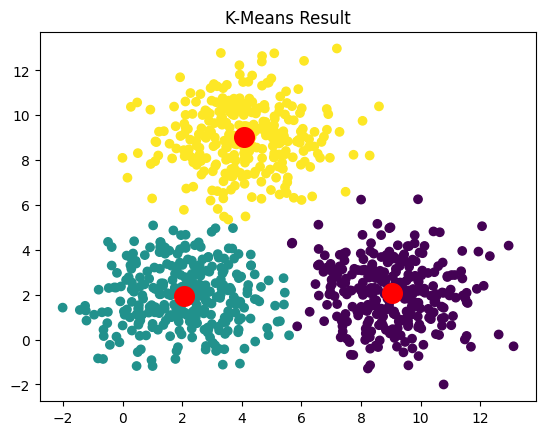

In [1]:
#bai1
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Tạo dữ liệu
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 300

X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.vstack((X0, X1, X2))

n_cluster = 3

# Khởi tạo tâm cụm
def init_centers(X, k):
    return X[np.random.choice(X.shape[0], k, replace=False)]

# Gán nhãn
def assign_labels(X, centers):
    distances = cdist(X, centers)
    return np.argmin(distances, axis=1)

# Cập nhật tâm
def update_centers(X, labels, k):
    centers = []
    for i in range(k):
        points = X[labels == i]
        centers.append(points.mean(axis=0))
    return np.array(centers)

# K-means chính
def kmeans(X, k):
    centers = init_centers(X, k)

    while True:
        labels = assign_labels(X, centers)
        new_centers = update_centers(X, labels, k)

        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return centers, labels

# RUN
centers, labels = kmeans(X, n_cluster)

# Vẽ
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200)
plt.title("K-Means Result")
plt.show()

In [ ]:
#bai 2
